In [10]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [11]:
FILES_PATH="./Figure4a_data/"

In [12]:
ad = pd.read_csv(f"{FILES_PATH}/ad_edge.csv", index_col=0)
ad_pval = pd.read_csv(f"{FILES_PATH}/ad_edge_p_val.csv", index_col=0)
ad_pval = ad_pval.loc[ad.index]

ctrl = pd.read_csv(f"{FILES_PATH}/ctl_edge.csv", index_col=0)
ctrl = ctrl.loc[ad.index]
ctrl_pval=pd.read_csv(f"{FILES_PATH}/ctl_edge_p_val.csv", index_col=0)
ctrl_pval=ctrl_pval.loc[ad.index]

In [13]:
ad.columns = ['AD prior','SCZ prior','Data-driven']
ctrl.columns = ['AD prior','SCZ prior','Data-driven']

In [14]:
ctrl_pval.columns = ['AD imp score', 'SCZ imp score', 'Data-driven imp score']
ad_pval.columns = ['AD imp score', 'SCZ imp score', 'Data-driven imp score','Combined imp score']

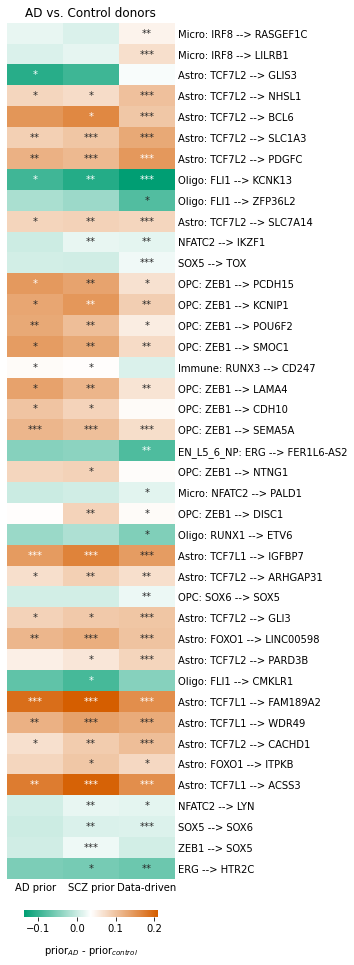

In [16]:
df1 = ad-ctrl
df1_pval = ad_pval.copy()

stars = []
for idx, row in df1_pval.iterrows():
    row_star=[]
    if row["AD imp score"]<0.001:
        row_star.append("***")
    elif row["AD imp score"]<0.01:
        row_star.append("**")
    elif row["AD imp score"]<0.05:
        row_star.append("*")
    else:
        row_star.append("")

    if row["SCZ imp score"]<0.001:
        row_star.append("***")
    elif row["SCZ imp score"]<0.01:
        row_star.append("**")
    elif row["SCZ imp score"]<0.05:
        row_star.append("*")
    else:
        row_star.append("")

    if row["Data-driven imp score"]<0.001:
        row_star.append("***")
    elif row["Data-driven imp score"]<0.01:
        row_star.append("**")
    elif row["Data-driven imp score"]<0.05:
        row_star.append("*")
    else:
        row_star.append("")
    stars.append(row_star)


heatmap_data1 = df1.values  # shape (10,1)

fig, ax = plt.subplots(figsize=(3, 20))
plt.subplots_adjust(wspace=0, top=0.85)

ad_hex = ['#009e73','#ffffff','#d55e00']  
ad_cmap = LinearSegmentedColormap.from_list('custom_cmap', ad_hex)

sns_heatmap = sns.heatmap(heatmap_data1,cmap=ad_cmap,ax=ax,cbar=True, annot=stars,fmt="s", 
    cbar_kws={
        "orientation": "horizontal",
        "pad": 0.03,         
        "shrink": 0.8        
    },)
ax.set_title('AD vs. Control donors')
ax.set_xlabel("")

ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

ax.tick_params(axis='x', which='both', bottom=False, top=False, length=0)
ax.tick_params(axis='y', which='both', bottom=False, top=False, length=0)

ax.set_yticklabels(df1.index)
ax.set_xticklabels(['AD prior', 'SCZ prior', 'Data-driven'])
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

colorbar = sns_heatmap.collections[0].colorbar
colorbar_title=r"prior$_{AD}$ - prior$_{control}$"
colorbar.set_label(colorbar_title, labelpad=10) 

# plt.savefig(f"./Figure4a/4a_donor_disease_priors.png", 
            # dpi=300, bbox_inches="tight")

plt.show()